# 03b - the NN gallery against classical baselines

Same panel, same cutoff, same held-out cells as notebook 03, with the Bayesian family
deliberately dropped. Nothing here compiles or samples a Stan model, so the notebook runs
end to end on a plain install with no compiler toolchain and no cmdstan.

What is left is the comparison this notebook exists for:

* the four neural entries - `nn_transformer`, `mdn`, `resnet`, `deeptriangle` - against
  the **deterministic Mack chain ladder**, on the next calendar diagonal, scored with
  CRPS, point error and PIT;
* and against **`sur`** (Zhang's multivariate chain ladder) at the **ultimate** level,
  where cross-line dependence is the one thing every entry on the board structurally
  cannot model.

The path is the same four steps as notebook 03, and it is still the point:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> gallery.align_panel(...)             # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

**Read this before running: the ELPD column comes out empty, on purpose.** `mack` has no
predictive density ever, and the four NN entries refuse one on every cohort of a
provenance-consistent panel. The section "Two boards, and one of them is empty" explains
why, and the DAGs in the middle of the notebook draw the mechanism. The board is
therefore CRPS, point error and PIT - which is exactly the set of scores a bootstrap
baseline and a mixture-density network can both answer.

## The self-containment contract

This notebook is meant to run **anywhere**: any working directory, inside a checkout of
the ibnr repository or nowhere near one.

* it never manipulates the import path, never imports from a repo directory, and never
  walks up the filesystem looking for a project root;
* it reads no committed result files - every number below comes from a live fit;
* the one screen it borrows (the Meyers company selection) is **imported from the
  data's own package**, `cas_schedule_p.screens`, which is pinned to a version - nothing
  is copied out of a repository, so nothing can go stale;
* all paths are resolved by the library from its own cache.

### Prerequisites

1. Python 3.11 or 3.12 (the package caps below 3.13).
2. `pip install "ibnr[nn]==0.5.2" cas-schedule-p==2026.6.13 matplotlib` - both
   versions are pinned. The notebook reads a few 0.5.2 internals (the neural data
   contract, the training scheme), and the screen package is the one that names the data
   publish everything below is asserted against. Asserts in the first cells hold you to
   both.
3. Read access to the Schedule P gold publish. The data repository is **public**, so its
   releases download over anonymous HTTPS - but ibnr 0.5.2's loader was written while the
   repository was private and shells out to the `gh` CLI regardless, so on this pinned
   version a **cold cache still needs `gh`, authenticated**. A warm cache needs nothing,
   and neither does the `cas-schedule-p` package, which carries the mart inside the
   wheel. The next section spells this out.

### What it costs

Essentially four pooled neural fits: 120 epochs x 5 ensemble members each, on a 25-cohort
panel. The 25 `mack` fits and the 10 `sur` fits are seconds. Every timing print is kept,
so the committed run publishes its own numbers rather than quoting somebody else's box.

### What it is not

25 cohorts at one cutoff on one field is a demonstration, not a study. The evidence lives
in the 200-company retrospectives shipped with the repository and in notebook 02. The
closing section says explicitly what this notebook does and does not claim.

In [1]:
# %pip install "ibnr[nn]==0.5.2" cas-schedule-p==2026.6.13 matplotlib

import datetime as dt
import platform
import sys
import time
import warnings

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, display

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    SCORE_DIRECTION,
    Absence,
    CohortForecast,
    align_panel,
    next_diagonal,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points

# The pin is not decoration. The transformer section below reaches into modules that are
# not public API (the neural data contract, the training scheme, the network class), and
# the panel assert further down pins a data publish. Both are 0.5.2 facts.
assert ibnr.__version__ == "0.5.2", (
    f"this notebook is pinned to ibnr 0.5.2 and found {ibnr.__version__}. "
    'Install the exact version:  pip install "ibnr[nn]==0.5.2" '
    "cas-schedule-p==2026.6.13 matplotlib"
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

T_START = time.perf_counter()  # the wall clock the closing cell reports

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(1997, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@1997"
PREMIUM_FIELD = "earned_premium"
# THE STUDY WINDOW. The triangle itself is cut to these accident years before
# anything is fitted, so every fit and every held-out cell rest on the same
# data. Accident years 1988 and 1989 are out of the study entirely; they are
# not merely left unscored.
ORIGINS = [dt.date(y, 1, 1) for y in range(1990, 1998)]
SEED_FIT = 11  # every torch init
SEED_DRAW = 7  # every predict_at() and predict() call

print("ibnr  ", ibnr.__version__)
print("python", sys.version.split()[0], platform.platform())

ibnr   0.5.2
python 3.12.13 Windows-11-10.0.26200-SP0


## Where the data comes from, and why the publish is pinned

The panel is built from Ethan's CAS Schedule P gold mart, which the package consumes as
an immutable GitHub **release**: one release per gold publish, tagged with its publish id
and carrying a manifest of sha256 sums.

Three practical facts, because this is the one external dependency in the notebook:

* **A cold cache still needs the `gh` CLI, authenticated.** The data repository is
  **public** now, so its release assets are ordinary anonymous HTTPS downloads - but
  ibnr 0.5.2's loader was written while the repository was private and shells out to
  `gh` either way, so on this pinned version the first run needs `gh` installed and
  logged in. It downloads the manifest and the mart parquet and verifies the sha256. If
  you cannot reach it, nothing below this cell will run.
* **A warm cache needs nothing.** Files land under `~/.cache/ibnr` (or `IBNR_CACHE_DIR`
  if you set it), and a pinned tag is read straight off disk - no network, no `gh`.
* **`IBNR_SCHEDULE_P_WAREHOUSE` is deliberately bypassed here.** The library consults that
  env var only when a source argument is left unspecified; every data call in this notebook
  names the publish explicitly, so the producer-side warehouse override never engages.

The tag below is a **concrete publish id, not a floating pointer**. Two reasons: a
floating tag has to be resolved through `gh` on every single run even when the data is
already cached, and - more importantly - the panel assert two cells down is a claim about
one specific publish. `active_publish_id` re-reads the cached manifest and the loader
refuses a manifest whose publish id disagrees with the tag, so the assert cannot pass by
accident.

Every one of the four data calls below is handed the same pinned string. That is what
keeps the whole notebook on one publish.

In [2]:
# --- provenance -------------------------------------------------------------
# A concrete publish id. With an explicit tag the gh CLI is needed only on a cold
# cache; a floating tag would need it on every run just to learn the tag.
SOURCE = pinned_source("github://EKtheSage/cas-schedule-p-data-model@20260613_041006")
PUBLISH_ID = active_publish_id(SOURCE)
assert PUBLISH_ID == "20260613_041006", PUBLISH_ID

MART = active_mart_path(SOURCE)
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", MART.name)

mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## The panel

Two mechanical screens, both re-derived below from the mart rather than pasted in.

1. **The Meyers screen** (the monograph's Table A.1): coefficient of variation of net
   earned premium, CV of the net/direct premium ratio, a complete 10x10 square, a premium
   and a loss floor, and Meyers' one excluded group. Run on all four lines it passes 60
   companies on two or more lines - the 152 `(company, line)` pairs the milestone-3 study
   scored.

2. **A positivity screen on paid increments.** Only companies with no negative paid
   increment anywhere in the training history survive, and only **10 companies are clean
   on every one of their screened lines**, giving 25 cohorts.

   The second screen was originally there so the over-dispersed Poisson entry could stay
   on the board without deleting cohorts from everyone else. That entry is not on *this*
   board - but the screen stays, because it is what defines the published panel. Dropping
   it would change the 25 cohorts and this notebook would stop being comparable, cohort
   for cohort, with notebook 03.

The size range is wide on purpose: over the study window the largest cohort carries about
twelve million (USD thousands) of mean earned premium and the smallest a couple of
hundred, so the board is not a study of one magnitude.

### Why the screen is imported rather than copied

The screen now ships with the data. `cas_schedule_p.screens` comes from the same
repository that publishes the gold mart, and the package on PyPI carries the very publish
it screens, so the notebook simply imports it: one home for the screen, pinned by a
package version instead of by a comment recording somebody's commit, and released in step
with the data it selects from. The next cell asserts that the package's `PUBLISH_ID` is
the publish this notebook loaded, so an import and a mart from different publishes is a
failure rather than a quiet mismatch.

Two earlier arrangements are now gone. Notebook 03 imported this function from the
repository's own script directory, found by walking up from the working directory, which
works inside a checkout and nowhere else. The first version of this notebook removed that
dependency by vendoring the function into a cell, verbatim, with a header comment naming
the commit it was copied at.

The package can also read the mart it bundles, but this notebook hands `select_companies`
the same cached parquet every other data call uses, so the whole notebook stays on one
file.

In [3]:
# The Meyers screen (the monograph's Table A.1), from the data's own package.
import cas_schedule_p
from cas_schedule_p import screens
from cas_schedule_p.screens import MEYERS_LINES, select_companies

assert cas_schedule_p.__version__ == "2026.6.13", (
    f"this notebook is pinned to cas-schedule-p 2026.6.13 and found {cas_schedule_p.__version__}"
)
# The screen and the mart must come from the SAME gold publish.
assert cas_schedule_p.PUBLISH_ID == PUBLISH_ID, (cas_schedule_p.PUBLISH_ID, PUBLISH_ID)
# And the cutoff the screen is written against is this notebook's AS_OF.
assert AS_OF.isoformat() == screens.AS_OF, (screens.AS_OF, AS_OF)

In [4]:
t0 = time.perf_counter()
passing = {ln: set(select_companies(MART, ln, 10_000)["company_code"]) for ln in MEYERS_LINES}
by_company: dict[str, list[str]] = {}
for ln, codes in passing.items():
    for c in codes:
        by_company.setdefault(c, []).append(ln)
multiline = {c: sorted(ls) for c, ls in by_company.items() if len(ls) >= 2}
print({ln: len(v) for ln, v in passing.items()})
print(
    f"companies passing on >=2 lines: {len(multiline)}  pairs: {sum(map(len, multiline.values()))}"
)

# --- positivity screen on the <=1997 training slice ---------------------------
# Deliberately over the FULL 1988-1997 history rather than the study window
# below. It is strictly conservative - a cohort with no negative paid increment
# over ten accident years has none over the eight the study keeps - and running
# it on the wider history is what keeps this panel identical to the one the
# published board used, so the two are comparable cohort for cohort.
scan = load_schedule_p(SOURCE, lines=MEYERS_LINES, companies=sorted(multiline)).expr.execute()
scan["eval_date"] = pd.to_datetime(scan["eval_date"])
scan["origin_period"] = pd.to_datetime(scan["origin_period"])
paid_train = scan[
    (scan["field"] == FIELD)
    & (scan["eval_date"] <= pd.Timestamp(AS_OF))
    & (scan["origin_period"].dt.year.between(1988, 1997))
]
clean_pairs = set()
for key, g in paid_train.groupby(["company_code", "line_of_business"]):
    increments = [
        np.diff(np.r_[0.0, gg.sort_values("dev_lag")["value"].to_numpy()])
        for _, gg in g.groupby("origin_period")
    ]
    if all((inc >= 0).all() for inc in increments):
        clean_pairs.add(key)
print(f"pairs with no negative paid increment in the training slice: {len(clean_pairs)}")

PANEL = {c: ls for c, ls in sorted(multiline.items()) if all((c, ln) in clean_pairs for ln in ls)}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"screens took {time.perf_counter() - t0:.1f}s")

# Recorded, so a future gold publish that moves the panel is LOUD rather than a
# board that silently compares different insurers to the published one. This is
# the second lock on provenance: the pinned publish id is the first.
EXPECTED_PANEL = {
    "10022": ["commercial_auto", "private_passenger_auto"],
    "14044": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "1767": [
        "commercial_auto",
        "other_liability",
        "private_passenger_auto",
        "workers_compensation",
    ],
    "18767": ["commercial_auto", "workers_compensation"],
    "2003": ["other_liability", "private_passenger_auto"],
    "25275": ["commercial_auto", "private_passenger_auto"],
    "27022": ["commercial_auto", "private_passenger_auto"],
    "2712": ["commercial_auto", "workers_compensation"],
    "620": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "7080": ["commercial_auto", "private_passenger_auto", "workers_compensation"],
}
assert PANEL == EXPECTED_PANEL, f"panel moved under publish_id {PUBLISH_ID}: {PANEL}"
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
for c, ls in PANEL.items():
    print(f"  {c:>6}  {', '.join(ls)}")

{'commercial_auto': 63, 'private_passenger_auto': 60, 'workers_compensation': 52, 'other_liability': 56}
companies passing on >=2 lines: 60  pairs: 152


pairs with no negative paid increment in the training slice: 87
screens took 4.2s

10 companies, 25 cohorts, 4 lines
   10022  commercial_auto, private_passenger_auto
   14044  commercial_auto, other_liability, private_passenger_auto
    1767  commercial_auto, other_liability, private_passenger_auto, workers_compensation
   18767  commercial_auto, workers_compensation
    2003  other_liability, private_passenger_auto
   25275  commercial_auto, private_passenger_auto
   27022  commercial_auto, private_passenger_auto
    2712  commercial_auto, workers_compensation
     620  commercial_auto, other_liability, private_passenger_auto
    7080  commercial_auto, private_passenger_auto, workers_compensation


### The panel triangle, and the study window

The study window is cut into the **data**, not into the scoring call. Everything
downstream - every fit, every `next_diagonal`, every realized ultimate - reads `tri`, so
"what the fits trained on" and "what the held-out census calls training" are the same
table by construction instead of two arguments that have to be kept in agreement.

In [5]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 25 screened pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri_full = tri_all.filter(_keep)

# The mart's display segment is dropped, and this is STILL load-bearing in 0.5.2 -
# checked by removing it and re-executing, which fails.
#
# The mart carries three segments; the neural data contract treats company_name as
# display-only, so a pooled NN fit is keyed on two. 0.5.0 added narrowing INSIDE the
# capability mixins (entry.at_cohort(seg).log_lik_at(wide_cells) re-keys the cells onto
# the view's schema, verifying each dropped value against the fitted cohort first), but
# log_lik_at on the POOLED entry - which is how this notebook scores the NN rows - is not
# on that path: the neural contract has no single-cohort `segment` key at all, so the
# mixin has no identity to verify a dropped value against and passes the cells through
# untouched. Dropping the column here keeps every path on one schema.
tri_full = tri_full.with_expr(tri_full.expr.drop("company_name"))

tri = tri_full.filter(tri_full.expr.origin_period.isin(ORIGINS))
print("segments:", tri.segments)
print(f"{tri_full.count()} rows loaded in {time.perf_counter() - t0:.1f}s")
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)
print(
    f"{tri.count()} rows inside the study window: accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year} ({len(ORIGINS)} of them)"
)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_paid_latest = _frame[
    (_frame["field"] == FIELD) & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
]
# Total earned premium over the window, per cohort - the denominator the ultimate-level
# appendix normalizes reserve errors by, so a $2M book and a $2B book are comparable.
PREMIUM_TOTAL = _prem.groupby(["company_code", "line_of_business"])["value"].sum().to_dict()
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_1997")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
pairs_table.round(0)

segments: ['company_code', 'line_of_business']
35000 rows loaded in 0.2s


14000 rows inside the study window: accident years 1990-1997 (8 of them)

units: USD thousands


,company_code,line_of_business,mean_earned_premium,paid_at_1997
0,1767,private_passenger_auto,12635198.0,65271145.0
1,2003,private_passenger_auto,1897574.0,8778907.0
2,1767,commercial_auto,368564.0,1479179.0
3,1767,workers_compensation,315899.0,1162383.0
4,7080,workers_compensation,291281.0,1147580.0
5,1767,other_liability,264061.0,1150600.0
6,7080,private_passenger_auto,205590.0,805616.0
7,2712,workers_compensation,90936.0,351754.0
8,620,other_liability,77036.0,228301.0
9,2003,other_liability,71516.0,127602.0


## The held-out question

`next_diagonal(triangle, as_of=..., fields=...)` answers one question: **given a fit
trained on everything visible at `as_of`, which cells is it scored on?** The answer is the
next calendar diagonal, one cohort at a time, with the next development lag read from the
data rather than assumed. Cells the fit could not have known about are excluded and the
reason is counted, not dropped silently (`new_origin`, `dev_beyond_trained`, ...).

Two choices below are load-bearing.

**`fields=["paid_loss", "reported_loss"]` for every cohort, even though the board is on
paid.** No entry on this board needs the second field - the joint paid-and-outstanding
model that did is not here. It is kept anyway, because the `HoldoutCells` objects are part
of the panel's identity: the second field contributes its own exclusion census, and
building the cells exactly as notebook 03 built them is what keeps the two boards'
fingerprints comparable. So `n_cells` reads 14 while the paid narrowing gives 7, and that
is correct.

**No `origins=` argument, because the triangle is already the study window.**
`next_diagonal` has one, and reaching for it here would be a mistake: it restricts the
*training* claims the census is computed from as well as the cells to be scored, so the
returned `HoldoutCells` would describe a training window narrower than the one the fits
actually consumed. `HoldoutCells.train_origins` is asserted below against `ORIGINS` for
all 25 cohorts, so the census and the fits cannot drift apart.

That leaves **7 held-out paid cells per cohort, 175 offered in total.** How many of those
each score actually rests on is decided later, by the intersection over that score's own
members.

In [6]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        # both fields, identical to notebook 03's census, so the two boards'
        # fingerprints and exclusion counts stay comparable
        fields=[FIELD, "reported_loss"],
        premium_field=PREMIUM_FIELD,
    )
print(f"25 x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK. train_origins is what the held-out census believes the fit
# was trained on. It has to be the study window itself, on every cohort, or the
# board scores one training set and describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all 25 cohorts)")

_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

25 x next_diagonal in 12.6s

('10022', 'commercial_auto'): n_cells=14 (both fields), paid=7
as_of       1997-12-31
eval_date   1998-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 2, 'no_predecessor': 0}
train_origins   1990-01-01 .. 1997-01-01 (all 25 cohorts)
paid cells per cohort: [7] | panel total: 175


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1991-01-01,96,1998-12-31,792.0,790.0,1061.0
1,10022,commercial_auto,paid_loss,1992-01-01,84,1998-12-31,626.0,623.0,1281.0
2,10022,commercial_auto,paid_loss,1993-01-01,72,1998-12-31,861.0,852.0,1393.0
3,10022,commercial_auto,paid_loss,1994-01-01,60,1998-12-31,842.0,806.0,1692.0
4,10022,commercial_auto,paid_loss,1995-01-01,48,1998-12-31,410.0,386.0,1371.0
5,10022,commercial_auto,paid_loss,1996-01-01,36,1998-12-31,331.0,252.0,1360.0
6,10022,commercial_auto,paid_loss,1997-01-01,24,1998-12-31,468.0,276.0,1652.0


## The roster: who can be scored on what

A forecast carries **two independent capabilities**, and the split is the reason this
board can be honest about entries with very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive **density** -> **ELPD**;
* `PredictsHeldout` -> `predict_at()` -> predictive **draws** -> **CRPS**.

An entry may have either, both, or neither, and the two are not redundant. `mack`'s
bootstrap draws perfectly well and has no stated observation model, so it has no ELPD
ever. `sur` subclasses **neither** mixin: it cannot appear in either score column at all,
which is why it gets an ultimate-level appendix at the end instead of a board row. That
is a gap in the entry, not in the panel.

The roster below is built from the live registry rather than typed out, so it cannot
disagree with the package it is running against. The `config_class` column is the same
idea one level down: it is how an entry names the dataclass its `fit(config=...)` takes,
which is what lets the NN fits below configure themselves without importing four modules
by path.

In [7]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density (ELPD)": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
                "config_class": getattr(cls.config_class, "__name__", "-"),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density (ELPD)'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density (ELPD)'] & ~roster['draws (CRPS)']).sum()} neither"
)
# The six this notebook uses, in the order they appear.
ON_THIS_BOARD = ["mack", "nn_transformer", "mdn", "resnet", "deeptriangle"]
display(roster[roster["entry"].isin([*ON_THIS_BOARD, "sur"])].reset_index(drop=True))
roster

15 registered entries; 8 density, 12 draws, 3 neither


,entry,family,density (ELPD),draws (CRPS),config_class
0,mack,deterministic,False,True,-
1,deeptriangle,nn,True,True,DeepTriangleConfig
2,mdn,nn,True,True,MDNConfig
3,nn_transformer,nn,True,True,TransformerConfig
4,resnet,nn,True,True,ResNetConfig
5,sur,statistical,False,False,-


,entry,family,density (ELPD),draws (CRPS),config_class
0,clark_growth_curve,bayesian,False,True,-
1,compartmental,bayesian,True,True,-
2,england_verrall_odp,bayesian,False,True,-
3,guszcza_growth_curve,bayesian,True,True,-
4,meyers_ccl,bayesian,True,True,-
5,meyers_csr,bayesian,True,True,-
6,mack,deterministic,False,True,-
7,deeptriangle,nn,True,True,DeepTriangleConfig
8,mdn,nn,True,True,MDNConfig
9,nn_transformer,nn,True,True,TransformerConfig


## The fits

Every entry is fitted with exactly the arguments in the next cell - nothing is tuned per
cohort, and the seeds are the ones notebook 03 used, so the numbers here and there are
comparable.

The two shapes on this board are worth naming before the timings make them obvious.
`mack` is fitted **once per cohort**: 25 small, independent estimators. The four neural
entries are fitted **once each, pooled over the whole 25-cohort panel**, then asked for
each cohort's forecast. That is how these architectures are meant to be used - a single
Schedule P triangle has 36 usable cells in this window, nowhere near enough to train an
attention model - but it means each NN row reaches its board position having seen roughly
25 times the loss history of the `mack` row beside it. Caveat 5 in the closing section
spells out what that costs the comparison; it also flatters the timing table, where a
pooled fit's cost is amortized over 25 cohorts.

In [8]:
# The methods section, in one dict.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
}
# mack's fit() takes NO seed - it is a deterministic estimator, and the randomness
# is in predict() / predict_at(), which the heldout_* knobs above configure.
#
# The NN entries fit ONCE, pooled over the whole panel, then predict per cohort.
# 120 epochs / 5 ensemble members is the demonstrative cut of the published study's
# 400 epochs - see the closing caveats.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)
NN_ENTRIES = ["nn_transformer", "mdn", "resnet", "deeptriangle"]

pd.DataFrame(
    [{"entry": k, "how": "per cohort", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": n, "how": "pooled fit", "config": str(NN_CONFIG)} for n in NN_ENTRIES]
)

,entry,how,config
0,mack,per cohort,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,nn_transformer,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
2,mdn,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
3,resnet,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
4,deeptriangle,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."


### The helper

This is the API surface the notebook exists to show, so it is written out rather than
hidden in a module. Note `Absence`: a missing array is never a bare `None`, because the
board has to distinguish "this entry has no density, ever" from "this run refused this
cohort". The vocabulary is closed - `fit_failed`, `no_cell_sampler`,
`no_predictive_density`, `not_offered`, `scorer_not_implemented`, `scoring_refused` - and
free text raises.

One line here is not in notebook 03: `point_row` also stashes the *draws* behind each
cohort's total ultimate. The multiline appendix needs them, because comparing a
single-line entry against `sur` at the company level means summing a company's lines
within a draw - and that sum is exactly the independence assumption `sur` exists to
relax.

In [9]:
refusals: list[dict] = []
point_rows: list[dict] = []
ultimate_draws: dict[tuple[str, tuple[str, str]], np.ndarray] = {}


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: the bootstrap / quasi-likelihood entries.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Ultimate-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs to 2007 and an unrestricted
    aggregate is silently ~2.4x inflated (a gotcha that has bitten this repo).
    """
    # ONE call shape for every entry. `segment` is a filter on the fit's own cohorts,
    # so a two-column key identifies the one cohort of a single-cohort fit keyed on
    # three, and names the cohort of a pooled fit keyed on two.
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW)
    outcome = entry.realized_ultimates(sub[key], segment=seg)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    row = dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )
    # Kept for the multiline appendix: the draw axis behind this cohort's total.
    # Recorded LAST, so a row that failed to build cannot leave draws behind with
    # no point row to pair them against.
    ultimate_draws[(name, key)] = np.asarray(pred.samples[:, i], dtype=float)
    return row


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [10]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the entry:
        # a fitted entry carries its draws, and 25 of them at a time is needless
        # memory for something that is never read again.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.1f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                       5.4s  (0.2s per cohort)



refusals so far: 0


In [11]:
# One pooled fit per entry over the WHOLE panel triangle, then 25 cohort forecasts
# off it. The cost therefore amortizes, and the clustering unit for any paired test
# on these rows is the FIT (the whole panel), not the cohort.
#
# Each entry names its own config dataclass, so there is nothing to import by path:
# gallery.get(name).config_class is the ClassVar the registry checks at registration.
nn_fits = {}
for name in NN_ENTRIES:
    ConfigCls = gallery.get(name).config_class
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring 25 cohorts)",
        flush=True,
    )

nn_transformer            77.1s  (pooled fit 65.2s + 11.9s scoring 25 cohorts)


mdn                       12.8s  (pooled fit 8.1s + 4.7s scoring 25 cohorts)


resnet                    22.3s  (pooled fit 16.5s + 5.8s scoring 25 cohorts)


deeptriangle              25.3s  (pooled fit 17.1s + 8.2s scoring 25 cohorts)


## Two boards, and one of them is empty

`align_panel` intersects the cells; `leaderboard` scores them. Because a forecast carries
two independent capabilities, **each score gets its own panel**: its own membership, its
own intersection of cells, and its own fingerprint, stamped on every board row so a number
always carries the set that produced it.

On this roster the ELPD panel has **no members at all**, and the two reasons are different
in kind - which is precisely what `elpd_status` is for.

* **`mack`: `na: no_predictive_density`.** Permanent, and about the entry. Its intervals
  come from a bootstrap with no stated observation model, so there is no density to
  evaluate. It is not refusing this panel; it has nothing to refuse with.
* **The four NN entries: `na: no_scored_cohorts`.** They *have* a density - a Gaussian
  mixture per cell - and they decline to report one on every cohort here. The scored
  diagonal is the one immediately past the fit's training window, so its deepest cell sits
  at exactly the deepest development lag the fit ever saw. Per cohort that lag is reached
  by a single accident year on the latest calendar diagonal, and the neural training
  scheme holds the latest diagonals out as its validation split. The pooled
  per-development normalizer therefore has **no** training context at that step, the step
  is *pinned*, and `log_lik_at` refuses rather than scoring against an untrained head.
  Moving the study window does not escape it - the frontier moves with the window.

So this board is **CRPS, point error and PIT**, and the empty ELPD column is a finding
about the held-out design rather than a verdict on the neural densities. `predict_at`
works at the pinned step throughout, which is why the NN entries keep every CRPS cell they
offer. The diagrams further down draw the mechanism; the "what the panel cost" cell
demonstrates it from this run's own records.

### How to read the rest of the board

* **ELPD is higher-is-better, CRPS is lower-is-better.** They point in opposite
  directions, which is why `SCORE_DIRECTION` is machine-readable and why `leaderboard()`
  has **no default sort and no `sort_by=`**: an average-rank column across two columns
  running opposite ways is nonsense, and the board refuses to invite one.
* **A missing score is `pd.NA`, never `0.0`** - which on this board would be
  simultaneously the best ELPD and the best CRPS there is. Every total is reduced in
  Python from the model's own array, because a grouped sum over an all-missing group
  returns 0.0 in pandas.
* **`n_draws_sample_min`** is the raw draw count behind the worst cell's CRPS, and it is
  not the same across rows here: `mack` draws 10,000 and the NN entries 500. CRPS from a
  finite sample is biased upward by roughly O(1/n_draws), so the smaller sample is
  penalised slightly - worth knowing before reading a close margin as a ranking.

In [12]:
panel = align_panel(forecasts, units=tri.meta.units)
print(repr(panel))
print()
print(
    f"ELPD panel: {panel.n_cells_for('elpd'):4d} cells over "
    f"{panel.n_cohorts_for('elpd')} cohorts | members {list(panel.elpd_members)}"
)
print(f"            fingerprint {panel.elpd_fingerprint}")
print(
    f"CRPS panel: {panel.n_cells_for('crps'):4d} cells over "
    f"{panel.n_cohorts_for('crps')} cohorts | members {list(panel.crps_members)}"
)
print(f"            fingerprint {panel.crps_fingerprint}")
print(f"union of the two panels: {panel.n_cells} cells")

ForecastPanel(paid_loss@1997 @ 1997-12-31, 5 models, 25 cohorts | elpd: 0 cells over [] | crps: 175 cells over ['deeptriangle', 'mack', 'mdn', 'nn_transformer', 'resnet'] | dropped=0)

ELPD panel:    0 cells over 0 cohorts | members []
            fingerprint e3b0c44298fc1c14
CRPS panel:  175 cells over 25 cohorts | members ['deeptriangle', 'mack', 'mdn', 'nn_transformer', 'resnet']
            fingerprint bca75d8a6a13005c
union of the two panels: 175 cells


In [13]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_elpd",
        "elpd_per_cell",
        "elpd_status",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("SCORE_DIRECTION:", SCORE_DIRECTION)
# elpd_per_cell and elpd_status are kept even though the column is all N/A: the two
# KINDS of N/A on this board mean different things, and the status column is where
# that distinction is legible.
view.sort_values("crps_per_cell").round(3)

SCORE_DIRECTION: {'elpd': 'higher_is_better', 'elpd_per_cell': 'higher_is_better', 'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_elpd,elpd_per_cell,elpd_status,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
1,mack,25,0,<NA>,na: no_predictive_density,175,560679.411,3203.882,10000
0,deeptriangle,25,0,<NA>,na: no_scored_cohorts,175,740762.866,4232.931,500
4,resnet,25,0,<NA>,na: no_scored_cohorts,175,768275.801,4390.147,500
2,mdn,25,0,<NA>,na: no_scored_cohorts,175,921511.828,5265.782,500
3,nn_transformer,25,0,<NA>,na: no_scored_cohorts,175,1897690.595,10843.946,500


In [14]:
# The full board, including the member lists and fingerprints every published
# number has to carry.
board

,task,as_of,model,n_cohorts,elpd_members,elpd_fingerprint,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,crps_members,crps_fingerprint,n_cells_crps,crps,crps_per_cell,crps_status,n_draws_density_min,n_draws_sample_min,n_cells_elpd_own,n_cells_elpd_dropped,n_cells_crps_own,n_cells_crps_dropped
0,paid_loss@1997,1997-12-31,deeptriangle,25,,e3b0c44298fc1c14,0,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"deeptriangle,mack,mdn,nn_transformer,resnet",bca75d8a6a13005c,175,740762.865621,4232.930661,scored,<NA>,500,0,0,175,0
1,paid_loss@1997,1997-12-31,mack,25,,e3b0c44298fc1c14,0,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"deeptriangle,mack,mdn,nn_transformer,resnet",bca75d8a6a13005c,175,560679.411092,3203.882349,scored,<NA>,10000,0,0,175,0
2,paid_loss@1997,1997-12-31,mdn,25,,e3b0c44298fc1c14,0,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"deeptriangle,mack,mdn,nn_transformer,resnet",bca75d8a6a13005c,175,921511.82758,5265.781872,scored,<NA>,500,0,0,175,0
3,paid_loss@1997,1997-12-31,nn_transformer,25,,e3b0c44298fc1c14,0,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"deeptriangle,mack,mdn,nn_transformer,resnet",bca75d8a6a13005c,175,1897690.595282,10843.946259,scored,<NA>,500,0,0,175,0
4,paid_loss@1997,1997-12-31,resnet,25,,e3b0c44298fc1c14,0,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"deeptriangle,mack,mdn,nn_transformer,resnet",bca75d8a6a13005c,175,768275.800778,4390.147433,scored,<NA>,500,0,0,175,0


## What the panel cost

`panel.dropped` names every cell a member offered and the panel could not use, and which
member lacked it. `panel.absences` is the census behind every N/A. `panel.coverage` says
what each model offered and what survived.

This is also where the empty ELPD column stops being a claim in prose: the refusals table
below is this run's own record of four entries declining a density on 25 cohorts each, and
the error text names the pinned development step.

In [15]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped.head(12))
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())

# Summarised, not listed: the NN density refusals alone are one per (entry, cohort),
# and a hundred near-identical lines would bury anything that is not one of them.
print("\nrun-level refusals recorded by the helper:", len(refusals))
_ref = pd.DataFrame(refusals)
if len(_ref):
    _ref["error (truncated)"] = _ref["error"].str.slice(0, 70)
    display(
        _ref.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )
display(panel.coverage)
display(
    panel.absences.groupby(["model", "axis", "reason", "scope"], as_index=False).agg(
        cohorts=("cohort", "nunique"), cells=("n_cells", "sum")
    )
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 0

run-level refusals recorded by the helper: 100


,model,axis,error (truncated),cohorts
0,deeptriangle,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
1,mdn,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
2,nn_transformer,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
3,resnet,density,ValueError('1 cell(s) sit at pinned dev step(s...,25


,model,n_cohorts_offered,is_elpd_member,elpd_status,n_cohorts_elpd,n_cells_elpd_own,n_cells_elpd_on_panel,n_cells_elpd_dropped,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,deeptriangle,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,175,0
1,mack,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,175,0
2,mdn,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,175,0
3,nn_transformer,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,175,0
4,resnet,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,175,0


,model,axis,reason,scope,cohorts,cells
0,deeptriangle,density,scoring_refused,cohort,25,175
1,mack,density,no_predictive_density,model,25,175
2,mdn,density,scoring_refused,cohort,25,175
3,nn_transformer,density,scoring_refused,cohort,25,175
4,resnet,density,scoring_refused,cohort,25,175


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,2,0,7
1,"(10022, private_passenger_auto)",0,2,0,7
2,"(14044, commercial_auto)",0,2,0,7
3,"(14044, other_liability)",0,2,0,7
4,"(14044, private_passenger_auto)",0,2,0,7
5,"(1767, commercial_auto)",0,2,0,7
6,"(1767, other_liability)",0,2,0,7
7,"(1767, private_passenger_auto)",0,2,0,7
8,"(1767, workers_compensation)",0,2,0,7
9,"(18767, commercial_auto)",0,2,0,7


## Ultimate-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the
model actually delivers: the predicted ultimate against what the later statements
revealed. Every row below comes from `entry.predict()` and `entry.realized_ultimates()` on
the same fits used above - `realized_ultimates` restricts to the origins the training
slice had, which on this study window is 1990-1997, and that is what keeps the mart's
later accident years out of the aggregate.

This is the table where the information asymmetry bites hardest: each NN row is a single
fit pooled over all 25 cohorts, and `mack` is 25 separate fits.

In [16]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the number a
# reserving audience reads, and it is NOT the mean of the per-cohort percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
print(
    "aggregate_pct_error is per model, over the cohorts that model produced an ultimate "
    "for, so the rows are not all over the same dollars."
)
for _m, _n in per_model.loc[per_model["cohorts"] < len(COHORTS), "cohorts"].items():
    _missed = sorted(r["cohort"] for r in refusals if r["model"] == _m and r["axis"] == "ultimate")
    print(
        f"  {_m}: {int(_n)} of {len(COHORTS)} cohorts - predict() refused {_missed}, so those "
        "dollars are out of both its numerator and its denominator."
    )
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
deeptriangle,25,-0.26,4.53,56.40,1.30
resnet,25,2.84,5.21,29.60,5.12
mack,25,1.72,5.24,24.31,1.13
mdn,25,3.07,5.73,15.00,4.87
nn_transformer,25,4.12,7.35,20.00,8.81


aggregate_pct_error is per model, over the cohorts that model produced an ultimate for, so the rows are not all over the same dollars.


model,deeptriangle,mack,mdn,nn_transformer,resnet
line_of_business,,,,,
commercial_auto,-3.0,8.9,2.9,5.8,4.0
other_liability,-13.3,-1.8,-6.2,-8.8,-5.0
private_passenger_auto,0.5,0.7,5.7,5.4,4.4
workers_compensation,1.0,2.0,3.6,1.2,2.2


## Calibration on the held-out cells

The PIT of a held-out cell is the fraction of predictive draws at or below the outcome. If
the predictive distribution is right, PITs are Uniform(0, 1), and `ks_uniformity` is the
two-sided KS test the Meyers retrospectives report (`D x 100`, with an asterisk when it
fails at 5%).

**The 5% band assumes independent observations and these cells are not independent.**
Three dependences, all of them real on this panel:

1. the 7 cells of a cohort come from one fit on one triangle, and they are consecutive
   development lags of neighbouring accident years;
2. the 25 cohorts are 10 companies, so cohorts sharing a company share its case-reserving
   practice and its calendar-year effects;
3. the four NN rows are **one pooled fit each**, so all of their cells come from a single
   estimation.

Under positive dependence the effective number of observations is smaller than `n`, the
null distribution of `D` is wider than `1.36/sqrt(n)`, and a test at that band
over-rejects. The cell-level table below is therefore **descriptive**: the statistic and
the p-p curve, with no critical value and no pass/fail column.

**The calibrated test runs one level up.** `predict_at` returns *joint* draws - each row is
one draw across all of a cohort's cells at once - so summing within a draw gives the
predictive distribution of that cohort's whole next diagonal, and the PIT of the realized
total is **one observation per cohort**. Dependence 1 is integrated out exactly rather than
adjusted for, and dependence 3 stops mattering for the null because every model is now
tested on one observation per cohort. What survives is dependence 2, disclosed rather than
corrected - 10 companies is far too few blocks to bootstrap. At this `n` the test has
little power against anything short of gross miscalibration, which is the honest state of
a 25-cohort demonstration.

In [17]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
cohort_pit_rows: list[dict] = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    if not on.any():  # the whole cohort fell off the CRPS panel
        continue
    collected.setdefault(f.model, []).append(p[on])
    # ONE PIT per cohort, off the SAME draws: sum the panel's cells within each draw
    # first, so the cohort's joint predictive of its next-diagonal total is what gets
    # tested and the within-cohort dependence is integrated out.
    totals = f.draws[:, on].sum(axis=1)
    cohort_pit_rows.append(
        dict(model=f.model, cohort=f.cohort, pit=float((totals <= values[on].sum()).mean()))
    )
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks = (
    pd.DataFrame(
        [
            {"model": m, "n_cells": r.n, "D x 100": 100 * r.statistic, "mean_pit": float(p.mean())}
            for m, p in pits.items()
            for r in [ks_uniformity(p)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
print(
    "DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent\n"
    "(7 per cohort from one fit, 25 cohorts over 10 companies, the four NN rows one\n"
    "pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below."
)
ks.round(3)

DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent
(7 per cohort from one fit, 25 cohorts over 10 companies, the four NN rows one
pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below.


,model,n_cells,D x 100,mean_pit
0,mack,175,14.810,0.444
1,deeptriangle,175,16.086,0.422
2,nn_transformer,175,16.229,0.412
3,resnet,175,17.800,0.401
4,mdn,175,18.543,0.396


In [18]:
cohort_pits = pd.DataFrame(cohort_pit_rows)
ks_cohort = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_cohorts": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["pit"].mean()),
            }
            for m, g in cohort_pits.groupby("model")
            for r in [ks_uniformity(g["pit"].to_numpy())]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
# Every model tested on the SAME cohorts, or the D values are not comparable and the
# shared critical value is not shared. The CRPS panel is what guarantees it.
_n = sorted(set(ks_cohort["n_cohorts"]))
assert len(_n) == 1, ks_cohort
_companies = cohort_pits["cohort"].map(lambda c: c[0]).nunique()
print(
    f"one PIT per cohort, from that cohort's joint next-diagonal total: n = {_n[0]} "
    f"cohorts over {_companies} companies,\ncritical value "
    f"{ks_cohort['critical 5% x 100'].iloc[0]:.1f}. Cohorts of one company "
    "still share its reserving practice, so these are\nnear-independent rather than "
    f"independent; and at n = {_n[0]} the test only sees gross miscalibration."
)
ks_cohort.round(3)

one PIT per cohort, from that cohort's joint next-diagonal total: n = 25 cohorts over 10 companies,
critical value 27.2. Cohorts of one company still share its reserving practice, so these are
near-independent rather than independent; and at n = 25 the test only sees gross miscalibration.


,model,n_cohorts,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,nn_transformer,25,27.80,27.2,0.042,False,0.337
1,resnet,25,34.60,27.2,0.005,False,0.300
2,deeptriangle,25,35.00,27.2,0.004,False,0.322
3,mdn,25,39.40,27.2,0.001,False,0.271
4,mack,25,48.78,27.2,0.000,False,0.221


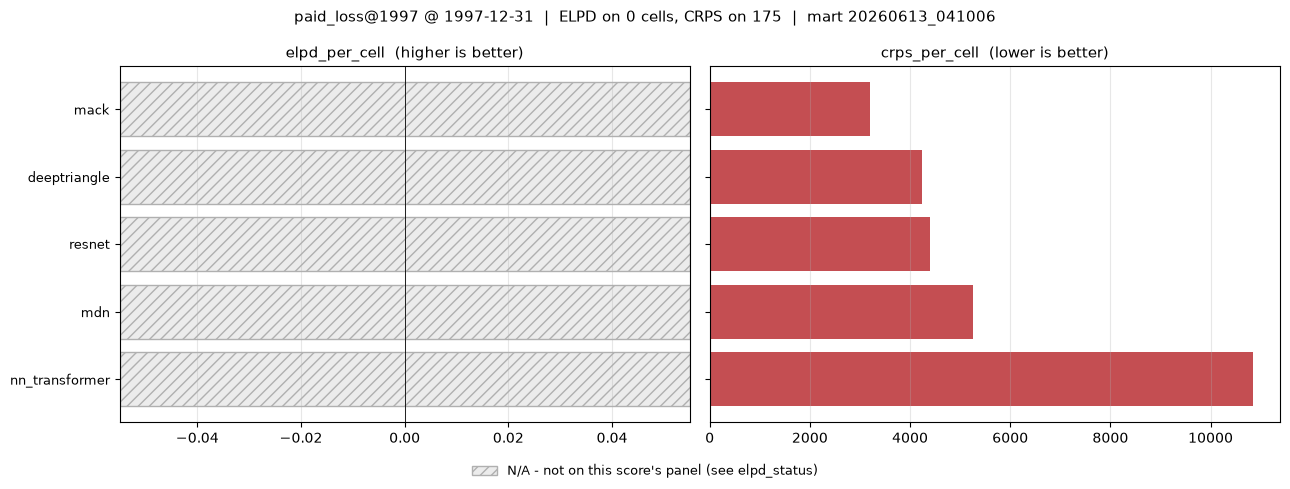

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 0.45 * len(board) + 2.6), sharey=True)
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))

for ax, col, direction in zip(
    axes, ["elpd_per_cell", "crps_per_cell"], ["higher is better", "lower is better"]
):
    vals = board.set_index("model").loc[order, col]
    have = vals.notna().to_numpy()
    v = pd.to_numeric(vals, errors="coerce").to_numpy(dtype=float)
    ax.barh(y[have], v[have], color="#4c72b0" if col.startswith("elpd") else "#c44e52")
    if (~have).any():
        # N/A is drawn as an explicit hatched band, never omitted and never plotted as
        # 0: 0 is the best value in BOTH columns. It spans the WHOLE row - a band the
        # width of the data would read as a bar with a value - and it is named once in
        # the figure legend. On this board that is the ENTIRE left panel, which is the
        # point of drawing it rather than dropping the column.
        x0, x1 = ax.get_xlim()
        for j, yy in enumerate(y[~have]):
            ax.barh(
                yy,
                x1 - x0,
                left=x0,
                color="#ececec",
                edgecolor="#b0b0b0",
                hatch="///",
                label="N/A - not on this score's panel (see elpd_status)"
                if j == 0
                else "_nolegend_",
            )
        ax.set_xlim(x0, x1)
    ax.set_yticks(y, order, fontsize=9)
    ax.set_title(f"{col}  ({direction})", fontsize=11)
    ax.axvline(0, color="black", lw=0.6)
    ax.grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    fig.legend(_handles[:1], _labels[:1], loc="lower center", frameon=False, fontsize=9)
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  ELPD on {panel.n_cells_for('elpd')} cells, "
    f"CRPS on {panel.n_cells_for('crps')}  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

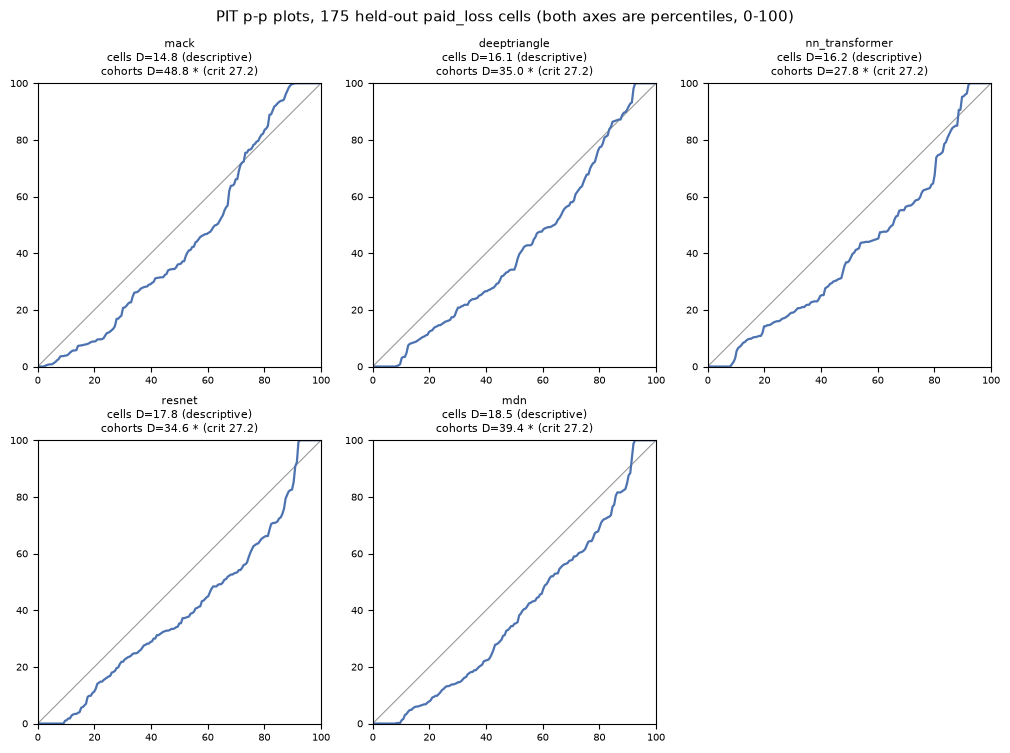

5 panels, [175] points each, on 0-100 axes


In [20]:
# pp_points returns PERCENTILES - (expected * 100, sorted PIT * 100), the Meyers
# convention the published retrospectives print. So the axes and the reference
# diagonal run 0-100 as well. Drawn against a [0, 1] diagonal with xlim/ylim (0, 1),
# every one of these points falls outside the window and the visible line is a
# clipping artifact, not the curve.
#
# The curves are the CELL-level PITs and are descriptive; the asterisk in each
# title is the COHORT-level test, which is the one with a valid null.
models = ks.sort_values("D x 100")["model"].tolist()
ncol = min(3, len(models))
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.8 * nrow), squeeze=False)
n_points = {}
_kc = ks_cohort.set_index("model")
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    n_points[m] = len(x)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    rc = _kc.loc[m]
    flag = "" if rc["passes"] else " *"
    ax.set_title(
        f"{m}\ncells D={r['D x 100']:.1f} (descriptive)\n"
        f"cohorts D={rc['D x 100']:.1f}{flag} (crit {rc['critical 5% x 100']:.1f})",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(
    f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells "
    "(both axes are percentiles, 0-100)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

# The panels contain their data, and this is what says so rather than the eye.
assert set(n_points.values()) == {panel.n_cells_for("crps")}, n_points
print(f"{len(n_points)} panels, {sorted(set(n_points.values()))} points each, on 0-100 axes")

## Inside the transformer: the network, not the API call

Everything above arrived through one line - `gallery.fit(name, triangle, ...)`. For a Stan
entry that is honest, because `model.stan` sits beside the entry and *is* the model. The
neural entries are not like that: the model is the network, the training scheme and the
rollout, and a `fit()` call hides all three. So this section opens `nn_transformer` up.

### The problem, and why attention

A loss triangle is a grid - accident year down the rows, development lag across the
columns. Cells on and above the latest diagonal have been observed; the cells below it have
to be predicted.

Chain ladder answers that one column at a time. The age-to-age factor at development step
*j* is estimated from column *j* against column *j+1* and looks at nothing else: not at how
this accident year behaved at 12 months, not at whether calendar year 1994 was bad across
the whole book, not at the other line of business the same company writes. That is `mack`,
the baseline on the board above, and its virtue is that every one of its assumptions is
written down.

The transformer treats **every (origin, dev) cell as a token** - the role a word plays in a
language model - and runs self-attention over the whole grid at once. Any cell can then
condition on any other cell: the same column (development), the same row (accident year),
the same diagonal (calendar year), or any combination the data supports. None of that is
hard-coded. Position enters as three learned embeddings, and the attention decides what to
use.

### What the small data forces

A 10x10 Schedule P triangle has 55 observed cells, and the eight accident years this
notebook keeps leave 36 of them per cohort. That is nowhere near enough to train an
attention model on one triangle, so two things hold for every design choice below:

* the fit is **pooled** - one network trained across every cohort in the panel at once,
  which is also why the NN rows on the board saw 25 triangles where the `mack` row saw one;
* the target is an **incremental loss ratio** - one development step's emergence divided by
  that origin's earned premium - so a $2M book and a $2B book sit on one scale and the
  network never has to reproduce the level of any individual triangle.

The three diagrams below split the entry into its three jobs: preparing the data, one
shared forward pass plus the loop that trains it, and inference. Line references point into
the installed package at 0.5.2, so you can read the code beside the picture.

### 1. Data preparation

`ibnr/kernels/nn_contract.py:176` (`nn_data`) is the only route from a `Triangle` to the
arrays a neural entry consumes - the neural analogue of the Stan data block. `fit()` calls
it on the **training slice** (`Triangle.as_of`, at
`ibnr/gallery/nn/transformer/model.py:104`), so an unsliced triangle cannot leak the
future in.

Three conventions in the returned contract carry everything downstream:

* **`x` holds incremental loss ratios, not losses.** Cell *(w, d)* is
  `(cumulative[d] - cumulative[d-1]) / premium[w]`. Increments rather than cumulatives,
  because successive cumulative cells are almost perfectly correlated and there is nothing
  in that for a model to learn; ratios rather than dollars, because that is the
  cross-cohort normalizer.
* **`obs_mask` marks a *usable increment*, not the presence of a cell.** An increment needs
  its immediate predecessor, so a cell whose predecessor is missing is masked out even
  though the triangle plainly holds it. Absent cells are stored as `x = 0.0`, and that zero
  is padding - never a claim that the increment was zero.
* **`cal_idx[w, d] = w + d + 1` is calendar time on a dense grid.** Cells sharing a
  `cal_idx` share an evaluation date, which is what makes a valuation date expressible as a
  single integer cutoff. It drives both the validation split and the training augmentation.

Then two steps that are shared by every neural entry
(`ibnr/gallery/nn/_scheme.py:20-71`), and are the reason this section exists at all:
`splits` holds out the **trailing observed calendar diagonals** as validation - validating
by evaluation date, the way the model is actually used, not by a random cell - and
`norm_stats` standardizes the target **within each development step**, from training
context cells only.

`norm_stats` is also where the empty ELPD column above comes from. A development step with
fewer than two context values - in practice the deepest, whose only observations sit on the
held-out diagonal - is *pinned*: its standardized value is **defined** as 0, the mean falls
back to all observed cells at that step, and the standard deviation is fixed at 1. That
rule replaced an earlier scheme that inherited an earlier step's statistics, and it took
the paid mean error from +14% to +4% in the milestone-3 retrospective. Its cost is exactly
what the board showed: a pinned step has no trained head, so the entry refuses to report a
density there.

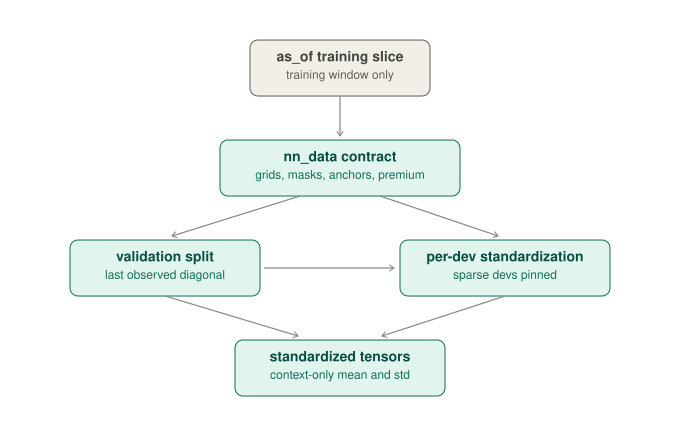

In [21]:
# a Triangle becomes standardized tensors
DAG_DATA_PREP = """<svg width="680" height="440" viewBox="0 0 680 440" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer data preparation</title>
<defs><marker id="dagprep-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<g>
<rect x="250" y="40" width="180" height="56" rx="8" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="340" y="58" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">as_of training slice</text>
<text x="340" y="76" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">training window only</text>
</g>
<line x1="340" y1="96" x2="340" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="220" y="140" width="240" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="340" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">nn_data contract</text>
<text x="340" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">grids, masks, anchors, premium</text>
</g>
<line x1="300" y1="196" x2="172" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="380" y1="196" x2="498" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="70" y="240" width="190" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="165" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">validation split</text>
<text x="165" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">last observed diagonal</text>
</g>
<g>
<rect x="400" y="240" width="210" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="505" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">per-dev standardization</text>
<text x="505" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">sparse devs pinned</text>
</g>
<line x1="264" y1="268" x2="394" y2="268" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="165" y1="296" x2="298" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="505" y1="296" x2="382" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="235" y="340" width="210" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="340" y="358" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">standardized tensors</text>
<text x="340" y="376" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">context-only mean and std</text>
</g>
</svg>"""

display(SVG(DAG_DATA_PREP))

### 2. One shared forward pass, and the loop that trains it

The striking thing about this architecture is how little of it is specific to a task.
**One** network serves the training loss, the validation score, the autoregressive rollout
and the held-out scorer; the only thing that changes between them is the pair *(which cells
are context, where the cutoff is)*.

The forward pass, in five moves
(`ibnr/gallery/nn/transformer/network.py`):

1. **tokens** (`:131-138`) - `x * flag` zeroes every non-context value and the grid is
   flattened to `T = W x D` tokens. The context flag is concatenated as an extra feature,
   which is what lets one network handle both roles: a predicted cell's token still exists
   and still attends, it just carries position and conditioning instead of a value.
2. **position** (`:66-74`) - three learned embeddings added per token: origin, development,
   and **distance past the conditioning cutoff**. The third is the one genuine research
   decision here. An absolute calendar embedding sounds more natural, but forecasting
   happens on diagonals *beyond* the training window, where an absolute embedding's rows
   never received a gradient - so earlier versions injected untrained parameters at exactly
   the cells being predicted.
3. **cohort conditioning** (`:146-147`) - the line of business as an 8-dimensional
   embedding plus the cohort's normalized log premium, added to all `T` tokens. Note what is
   *not* there: **no company embedding**. Roughly 600 companies with about 55 cells each is
   a memorization vector rather than a feature.
4. **attention** (`:80-89`) - two encoder layers, `d_model` 64, 4 heads, feed-forward width
   128, pre-layer-norm. There is **no attention mask**: every token attends to every other.
   The masking that matters is on the *values*, not on the attention. This is the step chain
   ladder has no analogue for.
5. **the MDN head** (`:151-167`) - a mixture weight, mean and scale per cell for each of
   `K = 3` Gaussian components. A lognormal head is unusable here because net-of-bulk
   increments go negative; a quantile head cannot produce coherent sums, and an ultimate is
   a sum of many future cells. A mixture gives a proper density that can be evaluated (what
   ELPD needs) and sampled (what CRPS, PIT and the rollout need).

The training loop adds three things:

* **calendar-cutoff augmentation** (`model.py:173-182`). Each epoch, each cohort is handed
  a *fake* valuation date drawn from inside the training window: condition on cells up to
  that diagonal, score the observed cells after it. One triangle becomes several distinct
  "predict the next diagonals" tasks - the main small-data multiplier, and what supervises
  the distance-past-cutoff embedding at every distance the rollout will later ask for.
* **a masked mixture NLL** (`network.py:170-189`). The network produced a distribution for
  every cell of every grid; the loss counts only the cells the mask names. Changing the mask
  changes the task without touching the network.
* **a five-member deep ensemble** (`ibnr/gallery/nn/_training.py:97-157`), AdamW with early
  stopping on the validation diagonals. The mixture supplies *aleatoric* spread - the
  irreducible noise in one cell; the ensemble supplies *epistemic* spread - disagreement
  about what the network should have been.

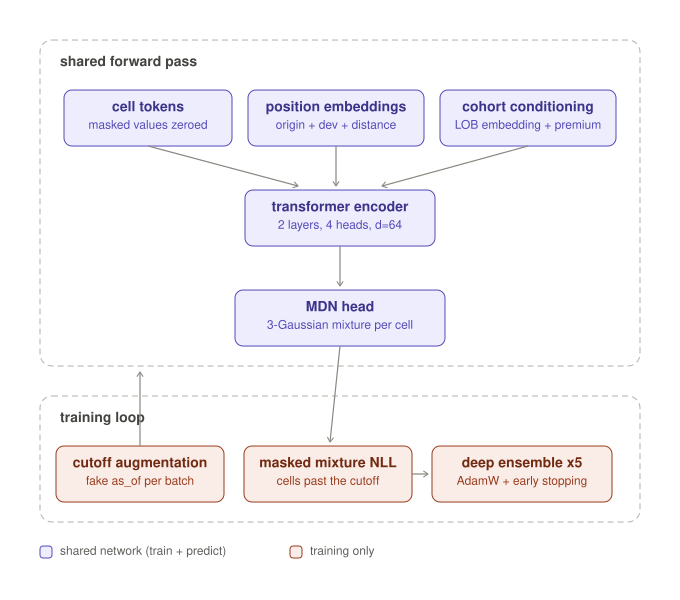

In [22]:
# one network, two callers
DAG_FORWARD_TRAINING = """<svg width="680" height="600" viewBox="0 0 680 600" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer forward pass and training loop</title>
<defs><marker id="dagfwd-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<rect x="40" y="40" width="600" height="326" rx="12" fill="none" stroke="#B4B2A9" stroke-width="1" stroke-dasharray="6 4"/>
<text x="60" y="66" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">shared forward pass</text>
<g>
<rect x="64" y="90" width="168" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="148" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">cell tokens</text>
<text x="148" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">masked values zeroed</text>
</g>
<g>
<rect x="248" y="90" width="176" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="336" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">position embeddings</text>
<text x="336" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">origin + dev + distance</text>
</g>
<g>
<rect x="440" y="90" width="176" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="528" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">cohort conditioning</text>
<text x="528" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">LOB embedding + premium</text>
</g>
<line x1="148" y1="146" x2="298" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="336" y1="146" x2="336" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="528" y1="146" x2="382" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<g>
<rect x="245" y="190" width="190" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="340" y="208" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">transformer encoder</text>
<text x="340" y="226" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">2 layers, 4 heads, d=64</text>
</g>
<line x1="340" y1="246" x2="340" y2="286" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<g>
<rect x="235" y="290" width="210" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="340" y="308" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">MDN head</text>
<text x="340" y="326" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">3-Gaussian mixture per cell</text>
</g>
<rect x="40" y="396" width="600" height="126" rx="12" fill="none" stroke="#B4B2A9" stroke-width="1" stroke-dasharray="6 4"/>
<text x="60" y="422" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">training loop</text>
<g>
<rect x="56" y="446" width="168" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="140" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">cutoff augmentation</text>
<text x="140" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">fake as_of per batch</text>
</g>
<g>
<rect x="244" y="446" width="168" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="328" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">masked mixture NLL</text>
<text x="328" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">cells past the cutoff</text>
</g>
<g>
<rect x="432" y="446" width="180" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="522" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">deep ensemble x5</text>
<text x="522" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">AdamW + early stopping</text>
</g>
<line x1="140" y1="446" x2="140" y2="372" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="340" y1="346" x2="330" y2="442" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="412" y1="474" x2="428" y2="474" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<rect x="40" y="546" width="12" height="12" rx="3" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="60" y="552" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">shared network (train + predict)</text>
<rect x="290" y="546" width="12" height="12" rx="3" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="310" y="552" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">training only</text>
</svg>"""

display(SVG(DAG_FORWARD_TRAINING))

### 3. Inference, and why the two scores behave differently

Scoring one held-out diagonal needs a single forward pass, because that diagonal sits one
step past everything the cohort has observed. An **ultimate** is different: it is the sum of
every remaining future cell, seven calendar diagonals deep on this panel, and the network
has never been trained to jump that far.

So `predict()` (`ibnr/gallery/nn/transformer/model.py:228-269`) does not jump. It walks
(`:328-431`), one calendar diagonal at a time - the transformer's analogue of the chain
ladder recursion. Sample every future cell on the next diagonal from its mixture, write the
samples into the grid as if they were data, promote them to context, re-encode the whole
grid, step on. Re-encoding buys two things: the predicted diagonal is always at **distance
1** past the context boundary, the relative position the cutoff augmentation supervised most
heavily, and the draws come out **jointly coherent** across a cohort's cells rather than
only marginally right - which is what makes a sum over cells (an ultimate, or the
cohort-total PIT tested above) a legitimate object rather than a sum of unrelated
marginals.

The last step back to dollars is `latest_cum + premium x (sum of sampled future ratios)`
(`:424-431`), with each ratio un-standardized by its own development step's statistics. The
network is only ever asked for increments and never for the level of the triangle.

**And here is the asymmetry the board ran into**, both halves of it living in the held-out
hooks at `ibnr/gallery/nn/_heldout.py:353-488`. At a *pinned* development step:

* the **density** refuses. There is no trained head there, and reporting a number would mean
  scoring against an untrained one.
* the **draws** answer. The rollout's convention at a pinned step is the pooled development
  mean - effectively a point mass at the step's average ratio. That is a weak prediction, and
  CRPS prices it as one, which is the right outcome: the model is penalised for knowing
  little rather than excused from being scored.

That is the whole reason `mack` and the four NN entries share a CRPS column and no ELPD
column: one has no density at all, and the others decline to state one exactly where this
panel asks.

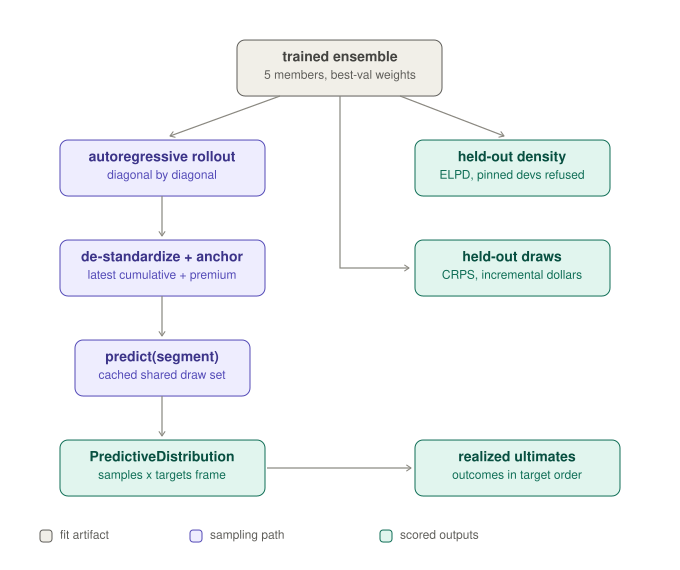

In [23]:
# from trained ensemble to scored outputs
DAG_INFERENCE_OUTPUTS = """<svg width="680" height="570" viewBox="0 0 680 570" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer inference and outputs</title>
<defs><marker id="daginf-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<g>
<rect x="237" y="40" width="205" height="56" rx="8" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="340" y="58" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">trained ensemble</text>
<text x="340" y="76" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">5 members, best-val weights</text>
</g>
<line x1="280" y1="96" x2="170" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<line x1="400" y1="96" x2="504" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<path d="M340 96 L340 268 L409 268" fill="none" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="140" width="205" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">autoregressive rollout</text>
<text x="162" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">diagonal by diagonal</text>
</g>
<g>
<rect x="415" y="140" width="195" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="512" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">held-out density</text>
<text x="512" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">ELPD, pinned devs refused</text>
</g>
<line x1="162" y1="196" x2="162" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="240" width="205" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">de-standardize + anchor</text>
<text x="162" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">latest cumulative + premium</text>
</g>
<g>
<rect x="415" y="240" width="195" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="512" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">held-out draws</text>
<text x="512" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">CRPS, incremental dollars</text>
</g>
<line x1="162" y1="296" x2="162" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="75" y="340" width="175" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="358" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">predict(segment)</text>
<text x="162" y="376" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">cached shared draw set</text>
</g>
<line x1="162" y1="396" x2="162" y2="436" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="440" width="205" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="162" y="458" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">PredictiveDistribution</text>
<text x="162" y="476" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">samples x targets frame</text>
</g>
<line x1="267" y1="468" x2="411" y2="468" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="415" y="440" width="205" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="517" y="458" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">realized ultimates</text>
<text x="517" y="476" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">outcomes in target order</text>
</g>
<rect x="40" y="530" width="12" height="12" rx="3" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="60" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">fit artifact</text>
<rect x="190" y="530" width="12" height="12" rx="3" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="210" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">sampling path</text>
<rect x="380" y="530" width="12" height="12" rx="3" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="400" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">scored outputs</text>
</svg>"""

display(SVG(DAG_INFERENCE_OUTPUTS))

### One live forward pass

The diagrams are hand-drawn; this cell is not. It builds the same contract `fit()` built,
constructs an untrained network with the same config the board's fits used, and reports the
shape at every stage of a real forward pass - captured with PyTorch forward hooks on the
live modules, so the shapes are what actually flowed rather than a recomputation. It also
prints the parameter count and the pinned development steps, which is the empty ELPD column
measured rather than asserted.

Nothing here is trained, and nothing here touches the board: it is the architecture, read
from the installed package.

In [24]:
import torch

from ibnr.gallery.nn._scheme import norm_stats, splits
from ibnr.gallery.nn.transformer.config import TransformerConfig as TransformerCfg
from ibnr.gallery.nn.transformer.network import TriangleTransformer
from ibnr.kernels.nn_contract import nn_data

# the same call fit() makes, with the arguments the board's NN fits use
nn_contract = nn_data(tri.as_of(AS_OF), loss_field=FIELD, premium_field=PREMIUM_FIELD)
n_c, n_f, n_w, n_d = nn_contract["x"].shape

demo_cfg = TransformerCfg(**NN_CONFIG)
torch.manual_seed(SEED_FIT)
demo_net = TriangleTransformer(
    demo_cfg, n_lob=len(nn_contract["lob_levels"]), n_features=n_f, n_w=n_w, n_d=n_d
).eval()

# the two shared training-scheme pieces from the data-preparation diagram
demo_ctx, demo_val, demo_cutoff = splits(
    nn_contract["obs_mask"], nn_contract["cal_idx"], demo_cfg.val_diagonals
)
demo_mean, demo_std, demo_pinned = norm_stats(nn_contract["x"], demo_ctx, nn_contract["obs_mask"])
demo_x = (nn_contract["x"] - demo_mean[None, :, None, :]) / demo_std[None, :, None, :]
demo_x = np.where(demo_pinned[None, :, None, :], 0.0, demo_x)
_pm, _ps = float(np.mean(nn_contract["log_premium"])), float(np.std(nn_contract["log_premium"]))

x_t = torch.tensor(demo_x, dtype=torch.float32)
ctx_t = torch.tensor(demo_ctx)
lob_t = torch.tensor(nn_contract["lob_idx"], dtype=torch.long)
prem_t = torch.tensor((nn_contract["log_premium"] - _pm) / _ps, dtype=torch.float32)
cut_t = torch.full((n_c,), demo_cutoff, dtype=torch.long)

stages = []
hooks = [
    mod.register_forward_hook(
        lambda m, args, out, nm=nm: stages.append(
            {
                "module": nm,
                "type": type(m).__name__,
                "input": str(tuple(args[0].shape)),
                "output": str(tuple(out.shape)),
            }
        )
    )
    for nm, mod in demo_net.named_children()
]
with torch.no_grad():
    demo_log_pi, demo_mu, demo_sigma = demo_net(x_t, ctx_t, lob_t, prem_t, cut_t)
for h in hooks:
    h.remove()

print(
    f"B = {n_c} cohorts, F = {n_f} channels, W = {n_w} origins, D = {n_d} devs, "
    f"T = {n_w * n_d} tokens, d_model = {demo_cfg.d_model}, K = {demo_cfg.n_components}"
)
display(pd.DataFrame(stages))
_wsum = demo_log_pi.exp().sum(-1)
print("returned log_pi / mu / sigma:", tuple(demo_log_pi.shape), "= (B, W, D, K)")
print(f"mixture weights sum to 1 everywhere: min {_wsum.min():.6f}, max {_wsum.max():.6f}")
print(f"per-cell distributions from this one forward pass: {demo_mu[..., 0].numel():,}")
print()

total_params = sum(p.numel() for p in demo_net.parameters())
encoder_params = sum(p.numel() for p in demo_net.encoder.parameters())
print(f"parameters: {total_params:,} total, {encoder_params:,} of them the two encoder layers")
print(f"training-context cells across the whole panel: {int(demo_ctx.sum()):,}")
print(f"validation cells held out by calendar date:    {int(demo_val.sum()):,}")
print(f"parameters per training-context cell:          {total_params / demo_ctx.sum():.0f}")
print()

_devs = [(d + 1) * nn_contract["dev_grain_months"] for d in range(n_d)]
display(
    pd.DataFrame(
        {
            "dev_lag": _devs,
            "context cells": [int(demo_ctx[:, :, d].sum()) for d in range(n_d)],
            "mean ratio": demo_mean[0],
            "sd ratio": demo_std[0],
            "pinned": demo_pinned[0],
        }
    ).round(5)
)
print(
    "The pinned row(s) are the deepest development step(s): their only observations sit on\n"
    "the held-out validation diagonal, so no training-context value reaches the normalizer,\n"
    "the head there is untrained, sd is fixed at 1 and the standardized value is defined as\n"
    "0. That is the whole of the empty ELPD column, measured rather than asserted."
)

B = 25 cohorts, F = 1 channels, W = 8 origins, D = 8 devs, T = 64 tokens, d_model = 64, K = 3


,module,type,input,output
0,value_proj,Linear,"(25, 64, 2)","(25, 64, 64)"
1,origin_emb,Embedding,"(64,)","(64, 64)"
2,dev_emb,Embedding,"(64,)","(64, 64)"
3,dist_emb,Embedding,"(25, 64)","(25, 64, 64)"
4,lob_emb,Embedding,"(25,)","(25, 8)"
5,cond_proj,Linear,"(25, 9)","(25, 64)"
6,drop,Dropout,"(25, 64, 64)","(25, 64, 64)"
7,encoder,TransformerEncoder,"(25, 64, 64)","(25, 64, 64)"
8,out_norm,LayerNorm,"(25, 64, 64)","(25, 64, 64)"
9,head,Linear,"(25, 64, 64)","(25, 64, 9)"


returned log_pi / mu / sigma: (25, 8, 8, 3) = (B, W, D, K)
mixture weights sum to 1 everywhere: min 1.000000, max 1.000000
per-cell distributions from this one forward pass: 1,600

parameters: 70,121 total, 66,944 of them the two encoder layers
training-context cells across the whole panel: 700
validation cells held out by calendar date:    200
parameters per training-context cell:          100



,dev_lag,context cells,mean ratio,sd ratio,pinned
0,12,175,0.19279,0.09674,False
1,24,150,0.17970,0.06523,False
2,36,125,0.11968,0.05518,False
3,48,100,0.08530,0.04918,False
4,60,75,0.05072,0.04129,False
5,72,50,0.03776,0.03830,False
6,84,25,0.01851,0.03113,False
7,96,0,0.00829,1.00000,True


The pinned row(s) are the deepest development step(s): their only observations sit on
the held-out validation diagonal, so no training-context value reaches the normalizer,
the head there is untrained, sd is fixed at 1 and the standardized value is defined as
0. That is the whole of the empty ELPD column, measured rather than asserted.


## Appendix: `sur`, and the one thing the board cannot do

Every entry on the board above models **one triangle at a time**. Even the pooled neural
entries do: they are trained across cohorts, but their per-cohort draws are independent, so
a company's commercial auto and workers compensation reserves come out of two unrelated
sampling paths. Adding those two ultimates together implicitly assumes independence, and
nobody who has run a reserving department believes that.

`sur` - Zhang's seemingly-unrelated-regressions multivariate chain ladder, fitted by
hand-rolled FGLS - is the entry that relaxes it. One fit per **company**, over that
company's screened lines, with a contemporaneous cross-line correlation estimated from the
residuals. At zero correlation it collapses to the volume-weighted chain ladder per line,
which is the sanity check worth knowing before reading the correlations it reports.

It subclasses **neither** held-out mixin (the roster cell shows this live), so it has no
board row at all. The comparison therefore has to happen at the ultimate level, where every
entry produces a number:

* each board entry's **company total** is the sum of its per-line total ultimates, summed
  *within a draw*, which is the independence assumption written out;
* `sur`'s company total comes from its own joint predictive.

So the PIT of a company's realized total is one observation per company for **every** model
here - n = 10, the same n, directly comparable - and the difference between the sums and the
joint is precisely the quantity in question.

Two disclosures. `copula_glm` is the gallery's other cross-line entry and notebook 03 fits
it alongside `sur`; it is left out here to keep this appendix to one comparison.
`nn_transformer_ml`, the multi-line transformer, is omitted on cost: its rollout samples
line by line per calendar diagonal, and a single pooled fit on this 10-company panel ran
past 10 minutes without completing when that was measured. That is the one number in this
notebook quoted from a separate measurement rather than from its own timing table.

In [25]:
ml_rows, corr_rows, ml_failures = [], [], []
ml_draws: dict[str, np.ndarray] = {}
t0 = time.perf_counter()
for company, lines in PANEL.items():
    ce = tri.expr
    ctri = tri.filter(ce.company_code == company)
    try:
        entry = gallery.fit("sur", ctri, loss_field=FIELD, as_of=AS_OF)
    except Exception as exc:
        # sur's FGLS has documented family limits (it whitens by 1/sqrt(C), so a
        # non-positive cumulative cell is refused); a refusal is a result, not a crash.
        ml_failures.append(dict(model="sur", company_code=company, error=repr(exc)[:180]))
        continue
    pred = entry.predict(seed=SEED_DRAW)
    outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    ml_draws[company] = np.asarray(pred.samples[:, i], dtype=float)
    ml_rows.append(
        dict(
            model="sur",
            company_code=company,
            n_lines=len(lines),
            predicted_total=float(pred.mean()[i]),
            sd=float(pred.std()[i]),
            realized_total=outcome[i],
            pct_error=100.0 * (pred.mean()[i] - outcome[i]) / outcome[i],
            outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
        )
    )
    # The quantity the single-line entries cannot produce.
    corr = entry.pooled_corr_
    off = corr[np.triu_indices_from(corr, k=1)]
    corr_rows.append(
        dict(
            company_code=company,
            n_lines=len(lines),
            mean_cross_line_corr=float(np.mean(off)),
            max_abs=float(np.max(np.abs(off))),
        )
    )
    del entry
print(f"{len(ml_rows)} sur fits in {time.perf_counter() - t0:.1f}s; {len(ml_failures)} refusals")
for f in ml_failures:
    print("  ", f)
display(pd.DataFrame(ml_rows).round(2))
print("estimated contemporaneous cross-line correlation, per company:")
display(pd.DataFrame(corr_rows).round(3))

10 sur fits in 2.3s; 0 refusals


,model,company_code,n_lines,predicted_total,sd,realized_total,pct_error,outcome_pct
0,sur,10022,2,53498.57,1292.97,52346.0,2.20,18.95
1,sur,14044,3,37593.87,641.78,37281.0,0.84,31.86
2,sur,1767,4,82536284.52,581936.63,81660998.0,1.07,6.35
3,sur,18767,2,223047.28,3232.82,210677.0,5.87,0.00
4,sur,2003,2,10789869.88,171792.36,10707190.0,0.77,32.13
5,sur,25275,2,83763.15,1166.65,88574.0,-5.43,100.00
6,sur,27022,2,56989.34,1095.31,54062.0,5.41,0.30
7,sur,2712,2,767278.34,8948.42,719725.0,6.61,0.00
8,sur,620,3,1109220.58,18485.87,1118853.0,-0.86,70.43
9,sur,7080,3,3018501.53,24661.16,2982600.0,1.20,7.27


estimated contemporaneous cross-line correlation, per company:


,company_code,n_lines,mean_cross_line_corr,max_abs
0,10022,2,0.317,0.317
1,14044,3,-0.053,0.341
2,1767,4,0.444,0.824
3,18767,2,-0.012,0.012
4,2003,2,0.381,0.381
5,25275,2,-0.362,0.362
6,27022,2,0.000,0.000
7,2712,2,0.165,0.165
8,620,3,-0.002,0.109
9,7080,3,0.027,0.147


In [26]:
# Company totals for every model on one footing.
#   board entries: sum a company's per-line total-ultimate draws WITHIN a draw, which
#                  is the independence assumption written out;
#   sur:           its own joint predictive of the company total.
_realized = points.set_index(["model", "company_code", "line_of_business"])["realized_ultimate"]
company_rows = []
for model in sorted({k[0] for k in ultimate_draws}):
    for company, lines in PANEL.items():
        keys = [(model, (company, ln)) for ln in lines]
        if not all(k in ultimate_draws for k in keys):
            continue  # this model did not produce an ultimate for every line
        if len({len(ultimate_draws[k]) for k in keys}) != 1:
            continue  # draw counts differ, so a within-draw sum is not defined
        draws = np.sum([ultimate_draws[k] for k in keys], axis=0)
        realized = float(sum(_realized.loc[(model, company, ln)] for ln in lines))
        premium = float(sum(PREMIUM_TOTAL[(company, ln)] for ln in lines))
        company_rows.append(
            dict(
                model=model,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(draws.mean()),
                sd=float(draws.std(ddof=1)),
                realized_total=realized,
                pct_error=100.0 * (draws.mean() - realized) / realized,
                error_pct_premium=100.0 * (draws.mean() - realized) / premium,
                outcome_pct=100.0 * float((draws <= realized).mean()),
            )
        )
for row in ml_rows:
    company = row["company_code"]
    premium = float(sum(PREMIUM_TOTAL[(company, ln)] for ln in PANEL[company]))
    err = row["predicted_total"] - row["realized_total"]
    company_rows.append({**row, "error_pct_premium": 100.0 * err / premium})
ult = pd.DataFrame(company_rows)

# The realized total is a property of the data, not of the model, so every model that
# covered a company should agree on it. Printed rather than asserted: sur restricts
# origins its own way, and a disagreement is worth seeing rather than crashing on.
_spread = ult.groupby("company_code")["realized_total"].agg(lambda s: s.max() / s.min() - 1.0)
print(f"max relative disagreement about a company's realized total: {_spread.max():.2e}")

ult_summary = (
    ult.groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        median_pct_error=("pct_error", "median"),
        mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
        mean_abs_error_pct_premium=("error_pct_premium", lambda s: s.abs().mean()),
        median_outcome_pct=("outcome_pct", "median"),
    )
    .sort_values("mean_abs_error_pct_premium")
)
print(
    "\nCompany-total ultimates. mean_abs_error_pct_premium is the premium-normalized\n"
    "reserve error - the metric that survives a panel spanning four orders of magnitude\n"
    "of premium, where a percentage-of-ultimate error does not."
)
display(ult_summary.round(2))
display(ult.pivot_table(index="company_code", columns="model", values="pct_error").round(1))

max relative disagreement about a company's realized total: 0.00e+00

Company-total ultimates. mean_abs_error_pct_premium is the premium-normalized
reserve error - the metric that survives a panel spanning four orders of magnitude
of premium, where a percentage-of-ultimate error does not.


,companies,median_pct_error,mean_abs_pct_error,mean_abs_error_pct_premium,median_outcome_pct
model,,,,,
deeptriangle,10,-0.00,2.77,0.19,48.70
sur,10,1.14,3.03,0.21,13.11
mack,10,1.19,3.04,0.21,13.60
resnet,10,4.83,4.51,0.31,7.40
mdn,10,5.82,4.80,0.33,1.00
nn_transformer,10,5.51,6.44,0.44,5.40


model,deeptriangle,mack,mdn,nn_transformer,resnet,sur
company_code,,,,,,
10022,2.4,2.1,7.3,7.1,4.5,2.2
14044,4.1,0.8,8.4,14.6,9.5,0.8
1767,1.8,1.1,4.9,9.4,5.5,1.1
18767,5.1,5.9,8.9,8.7,10.2,5.9
2003,-0.5,0.8,7.0,10.4,5.1,0.8
25275,-5.4,-5.5,0.6,1.1,-1.9,-5.4
27022,-0.1,5.4,6.8,3.9,5.4,5.4
2712,0.1,6.6,1.4,-1.2,0.7,6.6
620,-4.6,-0.8,-2.3,-3.1,-1.1,-0.9


n = [10] companies per model. At this n the KS test detects only gross
miscalibration, so read the mean PIT column at least as hard as the statistic:
a mean well below 0.5 says the realized total lands in the lower tail of the
predictive far more often than it should, i.e. the predictives are biased high
relative to their own spread.


,model,n_companies,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,deeptriangle,10,27.00,43.007,0.460,True,0.479
1,mack,10,45.77,43.007,0.030,False,0.269
2,sur,10,47.87,43.007,0.020,False,0.267
3,nn_transformer,10,49.80,43.007,0.014,False,0.313
4,resnet,10,51.00,43.007,0.011,False,0.252
5,mdn,10,58.40,43.007,0.002,False,0.201


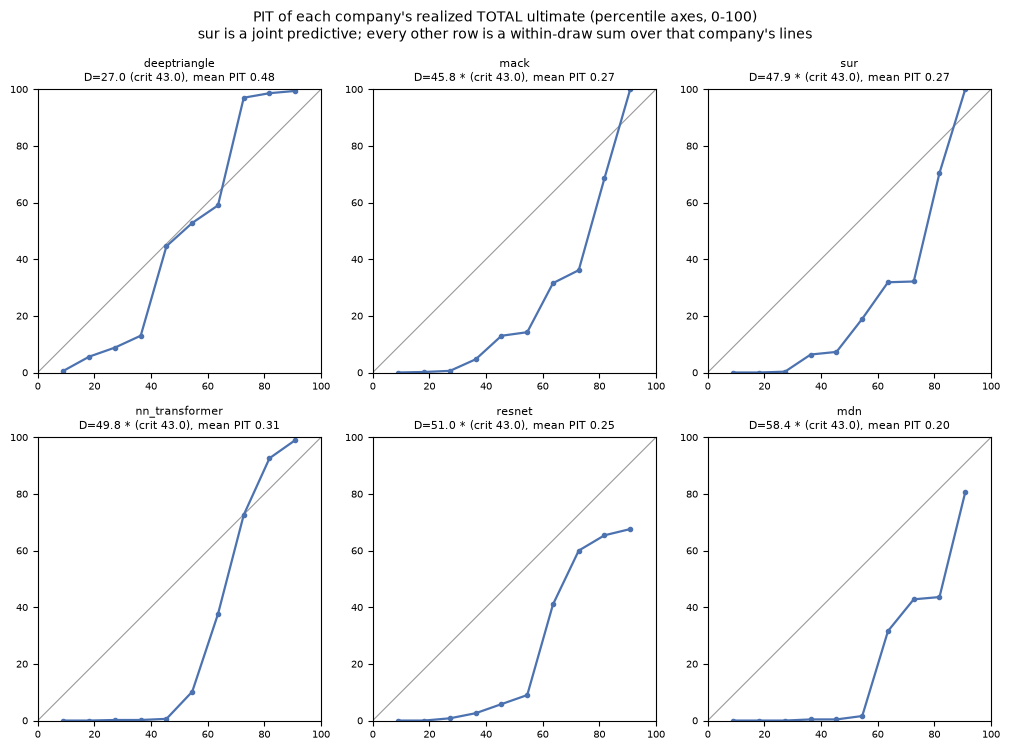

In [27]:
# Calibration at the company level: one PIT per company for every model, same n.
ks_ult = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_companies": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["outcome_pct"].mean() / 100.0),
            }
            for m, g in ult.groupby("model")
            for r in [ks_uniformity(g["outcome_pct"].to_numpy() / 100.0)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
_ns = sorted(set(ks_ult["n_companies"]))
print(
    f"n = {_ns} companies per model. At this n the KS test detects only gross\n"
    "miscalibration, so read the mean PIT column at least as hard as the statistic:\n"
    "a mean well below 0.5 says the realized total lands in the lower tail of the\n"
    "predictive far more often than it should, i.e. the predictives are biased high\n"
    "relative to their own spread."
)
display(ks_ult.round(3))

_models = ks_ult["model"].tolist()
ncol = min(3, len(_models))
nrow = int(np.ceil(len(_models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.8 * nrow), squeeze=False)
_ku = ks_ult.set_index("model")
for ax, m in zip(axes.ravel(), _models):
    p = ult.loc[ult["model"] == m, "outcome_pct"].to_numpy() / 100.0
    x, y = pp_points(p)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, marker="o", ms=3, color="#4c72b0")
    rc = _ku.loc[m]
    ax.set_title(
        f"{m}\nD={rc['D x 100']:.1f}{'' if rc['passes'] else ' *'} "
        f"(crit {rc['critical 5% x 100']:.1f}), mean PIT {rc['mean_pit']:.2f}",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(_models) :]:
    ax.axis("off")
fig.suptitle(
    "PIT of each company's realized TOTAL ultimate (percentile axes, 0-100)\n"
    "sur is a joint predictive; every other row is a within-draw sum over that "
    "company's lines",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## What this notebook does not claim

1. **It is a demonstration, not a study.** 10 companies, 25 cohorts, 175 held-out cells,
   one cutoff, one field. Rankings on a panel this small move with the panel. The evidence
   is the 200-company retrospectives shipped with the repository and notebook 02.
2. **The cohorts are not a random sample of the mart.** They passed the Meyers stability
   screens and were then filtered to companies with no negative paid increment anywhere in
   the training slice. Well-behaved data flatters every model here, and flatters the ones
   with the strongest positivity assumptions most.
3. **The neural entries run cut down, and they have no ELPD column at all.** 120 epochs and
   5 ensemble members against the published study's 400 epochs. Separately from the budget,
   their held-out density is refused on every cohort of a provenance-consistent panel,
   because the deepest scored cell is always a pinned development step. Reading that
   absence as a verdict on their densities would be wrong; it is a verdict on this held-out
   design.
4. **`mack` and the neural entries are not scored on the same number of draws.** 10,000
   against 500. Sample CRPS carries a small upward bias of order 1/n_draws, so the smaller
   sample is penalised slightly. It does not reverse a large gap and it can decide a small
   one.
5. **The NN rows did not see the same information as the row they are ranked against.** The
   four neural entries are fitted **once, pooled over all 25 cohorts**; `mack` is fitted on
   a single cohort's triangle, 25 times. Every NN row therefore reaches its board position
   having seen roughly 25 times the loss history of the row beside it. That is how these
   architectures are meant to be used - one Schedule P triangle is far too small to train
   one - but it makes this board an asymmetric-information comparison rather than a
   like-for-like one, and no panel object can correct for it. It also flatters the timing
   table.
6. **The Bayesian family is absent by construction, not by result.** Nothing here says a
   neural entry beats a hierarchical Bayesian one; notebook 03 is where that comparison
   lives, and on its board the best-calibrated paid entries were Bayesian. This notebook
   asks a narrower question - what the neural family buys over a classical baseline, on a
   machine with no Stan toolchain.
7. **The KS statistics are weak or descriptive everywhere.** The cell-level ones have no
   valid critical value at all (the cells are not independent). The cohort-level test has
   one observation per cohort but cohorts of one company are still correlated, and the
   company-level test in the appendix has n = 10. All three detect gross miscalibration and
   nothing finer. Neither is a substitute for the 200-company retrospectives, where the PIT
   sample is the study.
8. **The study window is eight accident years, 1990-1997, and that is a choice.** The
   triangle is cut to them before any fit, so the board loses the two deepest development
   lags - exactly where a growth-curve model would be most distinctive. What the window is
   NOT is a scoring-only restriction: cutting it into the data is what makes
   `HoldoutCells.train_origins` a true statement about every fit.

In [28]:
import torch  # noqa: F811  (re-imported so this cell stands alone if run on its own)

timings = (
    pd.DataFrame(
        [
            {"entry": k, "seconds": v, "seconds_per_cohort": round(v / len(COHORTS), 2)}
            for k, v in fit_seconds.items()
        ]
    )
    .sort_values("seconds", ascending=False)
    .reset_index(drop=True)
)
display(timings)
print(f"total fitting:   {timings['seconds'].sum() / 60:.1f} min")
print(f"notebook so far: {(time.perf_counter() - T_START) / 60:.1f} min wall clock")
print()
print("mart publish_id ", PUBLISH_ID)
print("panel           ", f"{len(PANEL)} companies, {len(COHORTS)} cohorts")
print("ELPD fingerprint", panel.elpd_fingerprint, "|", panel.n_cells_for("elpd"), "cells")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("cas-schedule-p  ", cas_schedule_p.__version__, "| publish", cas_schedule_p.PUBLISH_ID)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)
print("torch           ", torch.__version__)

,entry,seconds,seconds_per_cohort
0,nn_transformer,77.1,3.08
1,deeptriangle,25.3,1.01
2,resnet,22.3,0.89
3,mdn,12.8,0.51
4,mack,5.4,0.22


total fitting:   2.4 min
notebook so far: 2.9 min wall clock

mart publish_id  20260613_041006
panel            10 companies, 25 cohorts
ELPD fingerprint e3b0c44298fc1c14 | 0 cells
CRPS fingerprint bca75d8a6a13005c | 175 cells
ibnr             0.5.2
cas-schedule-p   2026.6.13 | publish 20260613_041006
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.5.1 3.0.5
torch            2.13.0+cpu
